# 18 - Travel-Time Weighted Network

So far we have treated every edge as one hop. That is useful for topology, but it makes a short urban segment and a long intercity segment cost exactly the same. In this notebook we want to replace hop count with scheduled seconds and see how much that changes routes and station importance.

We stream consecutive stop times from the raw feed and collect the full duration distribution for each directed segment. The median becomes the main edge cost, while the 25th and 75th percentiles preserve some information about schedule variation. We then build an undirected travel-time graph, compare hop-optimal and time-optimal routes, and recompute sampled betweenness with travel seconds as the weight.

Our question is: **which parts of the critical-station ranking are caused by graph topology, and which change when distance means scheduled travel time instead of number of stops?**

We use station and frequency tables from notebook 02 and the hop-based centrality table from notebook 04. The main outputs are `edges_traveltime.csv`, `graph_traveltime.pkl`, path comparisons, discard counts, travel-time betweenness, rank movers, figures, and `traveltime_summary.json`, all under `outputs/nb/18_travel_time_network/`.

## 1. Set up the working environment

We find the repository root, switch into it, and define the GTFS and shared output paths. The helper installs only missing packages and can clone the repository when the notebook runs in Colab. Every later file lookup uses these paths.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Load libraries and choose the cost settings

We import the graph, data, plotting, statistics, and serialization libraries. The standard `csv` reader handles the 816 MB file one row at a time, and `array('i')` stores duration observations much more compactly than Python integer lists.

We keep all runtime and filter choices together. The streaming pass normally takes a few minutes and keeps roughly 60 MB of raw integer payload. Weighted sampled betweenness is the main computation because every source requires Dijkstra rather than BFS; `RUN_BETWEENNESS` can skip it while testing. `K_BETWEENNESS = 200` and `N_PATH_PAIRS = 300` set the two sample sizes.

We accept durations from 1 second through 3 hours. Every observation outside that interval is counted by reason in the discard table, so we can see the effect of the threshold instead of hiding it.

In [2]:
_ensure("pandas", "numpy", "networkx", "matplotlib", "seaborn", "scipy")

import csv, json, pickle, random, time
from array import array
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
csv.field_size_limit(10_000_000)   # a few rows in the feed are unusually long

# ---------------- stage folders ----------------
STAGE = OUT / "18_travel_time_network"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# ---------------- modelling thresholds ----------------
MIN_TRAVEL_SECONDS = 1        # a segment must take strictly positive time
MAX_TRAVEL_SECONDS = 3 * 3600 # 3 hours: above this it is a feed error, not a bus ride
MIN_OBSERVATIONS = 1          # segments with fewer valid observations are dropped

# ---------------- cost knobs (see the table above) ----------------
PROGRESS_EVERY = 2_000_000    # progress print interval during the streaming pass
RUN_BETWEENNESS = True        # False -> skip the (slow) betweenness sections 9-11
K_BETWEENNESS = 200           # sampled sources for approximate betweenness
BETWEENNESS_SEED = 42         # same seed for both runs => same sampled source set
N_PATH_PAIRS = 300            # origin-destination pairs in the path comparison
PATH_SEED = 11
RANK_POOL = 500               # rank-mover analysis is restricted to this top-N pool
TOP_N = 15
FIG_DPI = 150

print("pandas", pd.__version__, "| networkx", nx.__version__)
print("stage folder:", STAGE)

pandas 3.0.5 | networkx 3.6.1
stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network


## 3. Prepare Hebrew labels

Some centrality tables and maps show Hebrew station names. We select a font with Hebrew glyphs and keep the raw logical-order strings because this Matplotlib version already displays them correctly. We do not run a separate bidi reordering step.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Load the graph attributes, frequencies, and hop baseline

We find the notebook 02 and 04 stage folders by prefix and load `nodes.csv`, `edges.csv`, and `stop_metrics.csv`. The station table supplies names and coordinates, the edge table supplies directed trip frequency, and the metric table supplies the existing sampled hop-betweenness values.

We build a dictionary for directed segment frequency and force station IDs to strings. Missing required artifacts stop the notebook immediately, because a time graph without station attributes or a comparison without the hop baseline would answer a different question.

In [4]:
def stage_dir(prefix, notebook_hint):
    """Resolve a stage folder by its two-digit prefix, e.g. '02' -> 02_graph_construction."""
    matches = sorted(p for p in OUT.glob(f"{prefix}*") if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            f"No stage folder matching '{prefix}*' under {OUT} - "
            f"run notebook {notebook_hint} first."
        )
    return matches[0]


def stage_file(prefix, filename, notebook_hint):
    """Return the path of `filename` inside stage `prefix`, searching sub-folders."""
    root = stage_dir(prefix, notebook_hint)
    direct = root / filename
    if direct.exists():
        return direct
    hits = sorted(root.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            f"'{filename}' not found anywhere under {root} - "
            f"run notebook {notebook_hint} first; it is the notebook that writes this file."
        )
    return hits[0]


NODES_CSV = stage_file("02", "nodes.csv", "02_graph_construction")
EDGES_CSV = stage_file("02", "edges.csv", "02_graph_construction")
METRICS_CSV = stage_file("04", "stop_metrics.csv", "04_centrality_analysis")

nodes_df = pd.read_csv(NODES_CSV, dtype={"stop_id": str}, encoding="utf-8-sig")
edges_df = pd.read_csv(EDGES_CSV, dtype={"from_stop": str, "to_stop": str}, encoding="utf-8-sig")

print(f"nodes.csv       : {len(nodes_df):,} rows  <- {NODES_CSV}")
print(f"edges.csv       : {len(edges_df):,} rows  <- {EDGES_CSV}")
print(f"stop_metrics.csv: found            <- {METRICS_CSV}")

ATTR = {
    str(r["stop_id"]): {
        "stop_name": ("" if pd.isna(r.get("stop_name")) else str(r.get("stop_name"))),
        "lat": (np.nan if pd.isna(r.get("lat")) else float(r.get("lat"))),
        "lon": (np.nan if pd.isna(r.get("lon")) else float(r.get("lon"))),
        "region": ("" if pd.isna(r.get("region")) else str(r.get("region"))),
        "metro": ("" if pd.isna(r.get("metro")) else str(r.get("metro"))),
    }
    for r in nodes_df.to_dict("records")
}
DEFAULT_ATTR = {"stop_name": "", "lat": np.nan, "lon": np.nan, "region": "", "metro": ""}

# Directed segment frequencies from stage 02, keyed exactly as edges.csv stores them.
FREQ = {(str(r["from_stop"]), str(r["to_stop"])): int(r["trip_frequency"])
        for r in edges_df.to_dict("records")}
print(f"directed segments with a known trip_frequency: {len(FREQ):,}")

nodes.csv       : 30,463 rows  <- /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/nodes.csv
edges.csv       : 51,999 rows  <- /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/edges.csv
stop_metrics.csv: found            <- /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis/tables/stop_metrics.csv
directed segments with a known trip_frequency: 51,999


## 5. Decode GTFS service-day times

GTFS allows hours greater than 23 so a trip can continue monotonically after midnight. We parse `HH:MM:SS` as `hour * 3600 + minute * 60 + second` without applying modulo 24. This makes `24:05:00` later than `23:57:00`, which is exactly what a within-trip duration needs.

The function returns `None` for blank or malformed values. The assertions include an eight-minute midnight crossing and show that wrapping the hour would incorrectly produce a large negative duration. We run these checks before the full scan because a time-decoding mistake would contaminate every edge weight.

In [5]:
def gtfs_seconds(value):
    """GTFS 'HH:MM:SS' -> seconds since *service* midnight. Hours >= 24 are legal.

    Returns None for blank or malformed input. Never uses datetime/strptime, which
    raises on '25:30:00' - see the markdown above.
    """
    if not value:
        return None
    s = value.strip()
    if not s:
        return None
    parts = s.split(":")
    if len(parts) != 3:
        return None
    try:
        h, m, sec = int(parts[0]), int(parts[1]), int(parts[2])
    except ValueError:
        return None
    return h * 3600 + m * 60 + sec


# --- lock the contract with tests -----------------------------------------
assert gtfs_seconds("00:00:00") == 0
assert gtfs_seconds("05:12:23") == 5 * 3600 + 12 * 60 + 23
assert gtfs_seconds("25:30:00") == 25 * 3600 + 30 * 60          # 91800, NOT 5400
assert gtfs_seconds(" 5:07:00") == 5 * 3600 + 7 * 60            # single-digit hour
assert gtfs_seconds("") is None and gtfs_seconds(None) is None
assert gtfs_seconds("not a time") is None

# The midnight-crossing case that a naive parser gets catastrophically wrong.
depart_u = gtfs_seconds("23:58:00")
arrive_v = gtfs_seconds("24:06:00")
assert arrive_v - depart_u == 8 * 60, "midnight-crossing segment must be +8 minutes"
naive_wrong = (gtfs_seconds("00:06:00") - depart_u) / 60.0
print(f"service-midnight parsing : {(arrive_v - depart_u) / 60:.0f} min  (correct)")
print(f"naive hour-mod-24 parsing: {naive_wrong:.0f} min  (silently wrong)")
print("gtfs_seconds passes all contract tests.")

service-midnight parsing : 8 min  (correct)
naive hour-mod-24 parsing: -1432 min  (silently wrong)
gtfs_seconds passes all contract tests.


## 6. Make sure `stop_times.txt` is present

We download the large stop-times file only if it is missing and print its local size. All duration observations come from this file, and the next cell reads it sequentially rather than loading it as a table.

In [6]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 7. Stream one duration distribution per directed segment

For every pair of consecutive rows in the same trip, we calculate `arrival at v - departure from u` using service-day seconds. If one time field is blank, we use the other field on that row. We also count rows where arrival and departure differ so we know whether the feed models dwell time separately.

The loop verifies that stop sequences do not go backward and that completed trip IDs do not reappear later. It skips self-loops, missing times, non-positive durations, and values above three hours, recording each reason separately. Valid seconds are appended to an `array('i')` keyed by directed station pair.

This is memory proportional to valid observations but with four bytes per duration rather than a full Python integer object. The cell prints progress, total rows, unique segments, and all order checks before we summarize the distributions.

In [7]:
def stream_segment_durations(path, progress_every=PROGRESS_EVERY):
    """One pass over stop_times.txt collecting the travel-time distribution per segment.

    Returns (durations, stats) where durations maps (u, v) -> array('i') of observed
    scheduled travel times in seconds. Memory is O(observations), never O(rows) in
    Python objects.
    """
    durations = defaultdict(lambda: array("i"))
    stats = dict(
        rows_read=0, trips_seen=0, segments_seen=0, kept=0,
        drop_self_loop=0, drop_missing_time=0, drop_nonpositive=0, drop_too_long=0,
        drop_sequence_regression=0,
        rows_missing_time=0, rows_with_dwell=0, rows_hour_ge_24=0,
        stop_sequence_regressions=0, interleaved_trip_blocks=0,
    )
    seen_trips = set()
    t0 = time.time()

    with open(path, encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        ti = header.index("trip_id")
        si = header.index("stop_id")
        ai = header.index("arrival_time")
        di = header.index("departure_time")
        qi = header.index("stop_sequence") if "stop_sequence" in header else None

        prev_trip = prev_stop = prev_dep = prev_seq = None
        for row in reader:
            stats["rows_read"] += 1
            trip = row[ti]
            stop = row[si]
            arr_raw, dep_raw = row[ai], row[di]
            seq = None
            if qi is not None:
                try:
                    seq = int(row[qi])
                except (ValueError, IndexError):
                    pass
            arr = gtfs_seconds(arr_raw)
            dep = gtfs_seconds(dep_raw)
            if arr is None and dep is None:
                stats["rows_missing_time"] += 1
            elif arr is not None and dep is not None and arr != dep:
                stats["rows_with_dwell"] += 1
            if arr is not None and arr >= 24 * 3600:
                stats["rows_hour_ge_24"] += 1
            # Fall back across the two columns; in this feed they are identical.
            arr_eff = arr if arr is not None else dep
            dep_eff = dep if dep is not None else arr

            if trip != prev_trip:
                if trip in seen_trips:
                    stats["interleaved_trip_blocks"] += 1
                seen_trips.add(trip)
                prev_seq = None
            else:
                stats["segments_seen"] += 1
                sequence_regression = (seq is not None and prev_seq is not None
                                       and seq <= prev_seq)
                if sequence_regression:
                    stats["stop_sequence_regressions"] += 1
                    stats["drop_sequence_regression"] += 1
                elif prev_stop == stop:
                    stats["drop_self_loop"] += 1
                elif prev_dep is None or arr_eff is None:
                    stats["drop_missing_time"] += 1
                else:
                    d = arr_eff - prev_dep
                    if d < MIN_TRAVEL_SECONDS:
                        stats["drop_nonpositive"] += 1
                    elif d > MAX_TRAVEL_SECONDS:
                        stats["drop_too_long"] += 1
                    else:
                        durations[(prev_stop, stop)].append(d)
                        stats["kept"] += 1

            prev_seq = seq

            prev_trip, prev_stop, prev_dep = trip, stop, dep_eff

            if progress_every and stats["rows_read"] % progress_every == 0:
                print(f"    {stats['rows_read']:,} rows | {len(durations):,} segments "
                      f"| {time.time() - t0:,.0f}s")

    stats["trips_seen"] = len(seen_trips)
    stats["distinct_segments"] = len(durations)
    stats["elapsed_seconds"] = round(time.time() - t0, 1)
    return durations, stats


print("Streaming stop_times.txt (~15.7M rows; 3-6 minutes) ...")
durations, stream_stats = stream_segment_durations(STOP_TIMES)

print("\nStreaming statistics:")
for k, v in stream_stats.items():
    print(f"  {k:<28} {v:,}" if isinstance(v, int) else f"  {k:<28} {v}")

if stream_stats["interleaved_trip_blocks"]:
    print("\n" + "!" * 78)
    print("ERROR: trip blocks are interleaved, so row adjacency is not trustworthy.")
    print("!" * 78)
    raise RuntimeError('stop_times.txt has interleaved trip blocks; sort it before rerunning')
elif stream_stats["stop_sequence_regressions"]:
    print(f"\nSkipped {stream_stats['stop_sequence_regressions']:,} locally out-of-order "
          "transitions. All other trip blocks were contiguous and remain valid.")
else:
    print("\nOrdering assumption holds over the full file - durations are trustworthy.")

Streaming stop_times.txt (~15.7M rows; 3-6 minutes) ...
    2,000,000 rows | 28,140 segments | 2s
    4,000,000 rows | 37,323 segments | 5s
    6,000,000 rows | 41,139 segments | 7s
    8,000,000 rows | 44,069 segments | 9s
    10,000,000 rows | 47,018 segments | 11s
    12,000,000 rows | 48,952 segments | 14s
    14,000,000 rows | 51,333 segments | 16s

Streaming statistics:
  rows_read                    15,711,624
  trips_seen                   420,133
  segments_seen                15,291,491
  kept                         15,196,433
  drop_self_loop               718
  drop_missing_time            0
  drop_nonpositive             93,778
  drop_too_long                0
  drop_sequence_regression     562
  rows_missing_time            0
  rows_with_dwell              0
  rows_hour_ge_24              152,485
  stop_sequence_regressions    562
  interleaved_trip_blocks      0
  distinct_segments            51,898
  elapsed_seconds              17.9

Skipped 562 locally out-of-order t

## 8. Account for every discarded observation

We turn the streaming counters into a table and assert that valid observations plus all discard buckets equal the number of consecutive stop pairs seen. The assertion makes the filtering mutually exclusive and complete.

The main loss in this feed is a zero-second duration when adjacent stops share the same minute-level timestamp. We discard these rather than invent a one-second edge, because artificially tiny weights would dominate Dijkstra routes. That choice biases surviving medians upward and can remove a very short segment if every recorded trip on it is zero.

In this run we keep 15,196,995 of 15,291,491 consecutive pairs (99.38%). There are 93,778 non-positive values, 718 self-loops, and no missing-time or over-three-hour observations. Arrival and departure are equal on every row, so the feed does not provide a separate dwell-time component.

consecutive stop pairs seen : 15,291,491
kept as observations        : 15,196,433 (99.38%)
rows where arrival != departure (dwell modelled): 0
rows with hour >= 24 (service-day convention)   : 152,485 (0.97%)


,reason,observations,share_of_pairs
0,kept (valid observation),15196433,0.993784
1,self-loop (u == v),718,0.000047
2,out-of-order stop_sequence,562,0.000037
3,missing / malformed time,0,0.000000
4,non-positive (< 1s),93778,0.006133
5,absurd (> 3h),0,0.000000


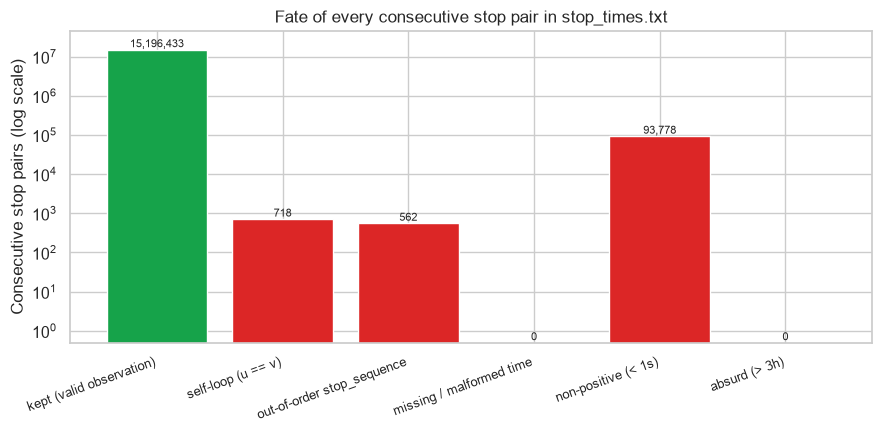

In [8]:
buckets = {
    "kept (valid observation)": stream_stats["kept"],
    "self-loop (u == v)": stream_stats["drop_self_loop"],
    "out-of-order stop_sequence": stream_stats["drop_sequence_regression"],
    "missing / malformed time": stream_stats["drop_missing_time"],
    f"non-positive (< {MIN_TRAVEL_SECONDS}s)": stream_stats["drop_nonpositive"],
    f"absurd (> {MAX_TRAVEL_SECONDS // 3600}h)": stream_stats["drop_too_long"],
}
total_pairs = stream_stats["segments_seen"]
assert sum(buckets.values()) == total_pairs, "discard buckets must account for every pair"

discard_df = pd.DataFrame({
    "reason": list(buckets.keys()),
    "observations": list(buckets.values()),
})
discard_df["share_of_pairs"] = (discard_df["observations"] / total_pairs).round(6)
discard_df.to_csv(TABLES / "discard_reasons.csv", index=False, encoding="utf-8-sig")

print(f"consecutive stop pairs seen : {total_pairs:,}")
print(f"kept as observations        : {stream_stats['kept']:,} "
      f"({stream_stats['kept'] / total_pairs:.2%})")
print(f"rows where arrival != departure (dwell modelled): {stream_stats['rows_with_dwell']:,}")
print(f"rows with hour >= 24 (service-day convention)   : {stream_stats['rows_hour_ge_24']:,} "
      f"({stream_stats['rows_hour_ge_24'] / stream_stats['rows_read']:.2%})")
display(discard_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#16a34a"] + ["#dc2626"] * (len(discard_df) - 1)
bars = ax.bar(range(len(discard_df)), discard_df["observations"], color=colors)
ax.set_yscale("log")
ax.set_ylim(bottom=0.5, top=discard_df["observations"].max() * 3)
ax.set_xticks(range(len(discard_df)))
ax.set_xticklabels(discard_df["reason"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Consecutive stop pairs (log scale)")
ax.set_title("Fate of every consecutive stop pair in stop_times.txt")
for b, v in zip(bars, discard_df["observations"]):
    ax.text(b.get_x() + b.get_width() / 2, max(v, 0.5), f"{v:,}",
            ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "discard_reasons.png", dpi=FIG_DPI)
plt.show()

## 9. Convert observations to directed edge weights

For each directed segment with enough observations we calculate median, p25, p75, and observation count. The median is the routing weight because it is robust to occasional long scheduled gaps. The interquartile range shows how much one number hides variation across trips.

We attach the directed trip frequency from notebook 02. Comparing frequency with valid-observation count reveals segments whose time estimate rests on only a small share of scheduled trips. We then pool raw observations from both directions under one unordered pair; taking the pooled median weights the two directions by their actual number of observations and is not the same as averaging two medians.

The directed CSV contains 51,907 segments in this run. Ninety-two of notebook 02's 51,999 directed segments have no valid duration, and 189 retained segments rely on one observation.

In [9]:
records = []
pooled = defaultdict(list)     # (min_id, max_id) -> list of numpy arrays

for (u, v), arr in durations.items():
    if len(arr) < MIN_OBSERVATIONS:
        continue
    a = np.asarray(arr, dtype=np.int32)
    p25, med, p75 = np.percentile(a, [25, 50, 75])
    records.append({
        "from_stop": u,
        "to_stop": v,
        "median_travel_seconds": float(round(med, 1)),
        "p25_travel_seconds": float(round(p25, 1)),
        "p75_travel_seconds": float(round(p75, 1)),
        "trip_frequency": int(FREQ.get((u, v), len(arr))),
        "n_observations": int(len(arr)),
    })
    pooled[(u, v) if u <= v else (v, u)].append(a)

tt_edges = pd.DataFrame.from_records(records)
tt_edges = tt_edges[["from_stop", "to_stop", "median_travel_seconds",
                     "p25_travel_seconds", "p75_travel_seconds",
                     "trip_frequency", "n_observations"]]
tt_edges.to_csv(TABLES / "edges_traveltime.csv", index=False, encoding="utf-8-sig")

# How many stage-02 segments could not be given a travel time at all?
missing_directed = sorted(set(FREQ) - set(zip(tt_edges["from_stop"], tt_edges["to_stop"])))
print(f"directed segments with a travel time : {len(tt_edges):,}")
print(f"stage-02 segments with NO valid observation: {len(missing_directed):,} "
      f"({len(missing_directed) / max(len(FREQ), 1):.2%} of stage-02 edges)")
print(f"total observations behind the table  : {tt_edges['n_observations'].sum():,}")
print(f"median observations per segment      : {tt_edges['n_observations'].median():.0f}")
print(f"segments resting on a single observation: "
      f"{(tt_edges['n_observations'] == 1).sum():,}")
display(tt_edges.head(TOP_N))

directed segments with a travel time : 51,898
stage-02 segments with NO valid observation: 101 (0.19% of stage-02 edges)
total observations behind the table  : 15,196,433
median observations per segment      : 132
segments resting on a single observation: 189


,from_stop,to_stop,median_travel_seconds,p25_travel_seconds,p75_travel_seconds,trip_frequency,n_observations
0,38725,15582,143.0,143.0,143.0,112,112
1,15582,15583,57.0,57.0,60.0,216,216
2,15583,16086,71.0,60.0,71.0,152,152
3,16086,16085,48.0,38.0,54.0,186,186
4,16085,16084,50.0,26.0,50.0,152,152
5,16084,15769,63.0,60.0,64.0,166,166
6,15769,15739,34.0,25.0,34.0,214,214
7,15739,15542,57.0,57.0,60.0,451,451
8,15542,15543,43.0,35.0,57.0,559,559
9,15543,16155,45.0,37.0,54.0,331,331


### Build and save the undirected travel-time graph

We create an undirected graph from the pooled direction arrays and copy station attributes from notebook 02. Each edge stores the pooled median as both `travel_seconds` and `weight`, plus summed trip frequency. In this graph, NetworkX's default `weight='weight'` now means seconds rather than service frequency.

The graph has 30,463 nodes and 51,680 edges. Its largest component contains 30,231 nodes, or 99.24%, and no station is lost entirely even though 92 directed segments lack usable time observations.

After saving `graph_traveltime.pkl`, we delete the raw duration arrays to free memory before the path and betweenness calculations.

In [10]:
Gt = nx.Graph()
for (a, b), arrs in pooled.items():
    all_obs = np.concatenate(arrs)
    med = float(np.median(all_obs))
    freq = int(FREQ.get((a, b), 0)) + int(FREQ.get((b, a), 0))
    Gt.add_edge(a, b,
                travel_seconds=med,
                weight=med,                 # mirror: nx defaults to weight="weight"
                trip_frequency=freq,
                n_observations=int(all_obs.size))

for n in Gt.nodes():
    Gt.nodes[n].update(ATTR.get(n, DEFAULT_ATTR))

# Portable contract for downstream rerouting: these are the pooled medians used
# by the actual undirected travel-time graph (not the fastest directed median).
undirected_tt_edges = pd.DataFrame([
    {'from_stop': a, 'to_stop': b,
     'median_travel_seconds': float(data['travel_seconds']),
     'trip_frequency': int(data['trip_frequency']),
     'n_observations': int(data['n_observations'])}
    for a, b, data in Gt.edges(data=True)
])
undirected_path = TABLES / 'edges_traveltime_undirected.csv'
undirected_tmp = undirected_path.with_suffix('.csv.tmp')
undirected_tt_edges.to_csv(undirected_tmp, index=False, encoding='utf-8-sig')
undirected_tmp.replace(undirected_path)

del durations, pooled

with open(STAGE / "graph_traveltime.pkl", "wb") as f:
    pickle.dump(Gt, f)

components = sorted(nx.connected_components(Gt), key=len, reverse=True)
Gc = Gt.subgraph(components[0]).copy()
lcc_share = Gc.number_of_nodes() / Gt.number_of_nodes()

print(f"travel-time graph : {Gt.number_of_nodes():,} nodes, {Gt.number_of_edges():,} edges")
print(f"connected components: {len(components):,}; "
      f"largest holds {Gc.number_of_nodes():,} nodes ({lcc_share:.2%})")
print(f"saved: {STAGE / 'graph_traveltime.pkl'} "
      f"({(STAGE / 'graph_traveltime.pkl').stat().st_size / 1024**2:.1f} MB)")

# Explicit comparison against the hop graph of notebook 02.
hop_nodes = set(nodes_df["stop_id"].astype(str))
print(f"\nstage-02 hop graph nodes: {len(hop_nodes):,}")
print(f"nodes lost to the travel-time filter: {len(hop_nodes - set(Gt.nodes())):,} "
      "(all of their segments had zero or unusable durations)")

travel-time graph : 30,463 nodes, 51,673 edges
connected components: 17; largest holds 30,224 nodes (99.22%)
saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/graph_traveltime.pkl (5.4 MB)

stage-02 hop graph nodes: 30,463
nodes lost to the travel-time filter: 0 (all of their segments had zero or unusable durations)


## 10. Inspect the edge-time distributions

We make three diagnostic plots: the distribution of median segment time, relative interquartile spread, and median time against trip frequency. These checks can reveal zero-weight mistakes, clipping at the three-hour ceiling, or a suspicious one-to-one relationship between frequency and time.

In this run the median edge is 66 seconds, the 90th percentile is 240 seconds, and the 99th is about 22.8 minutes. Only 0.70% of segments exceed 30 minutes. More than 30,000 segments have a zero-width IQR, showing that many timetable entries repeat exactly. Frequency and duration have Spearman correlation -0.367, so travel time adds information rather than acting as a simple transform of service count.

Median travel time per segment (seconds): p1=7  p25=45  p50=66  p75=120  p90=240  p99=1367
in minutes: p50=1.1  p90=4.0  p99=22.8
segments over 30 minutes: 365 (0.70%)
median relative IQR (p75-p25)/median: 0.00
segments with a zero-width IQR (identical on every trip): 30,269


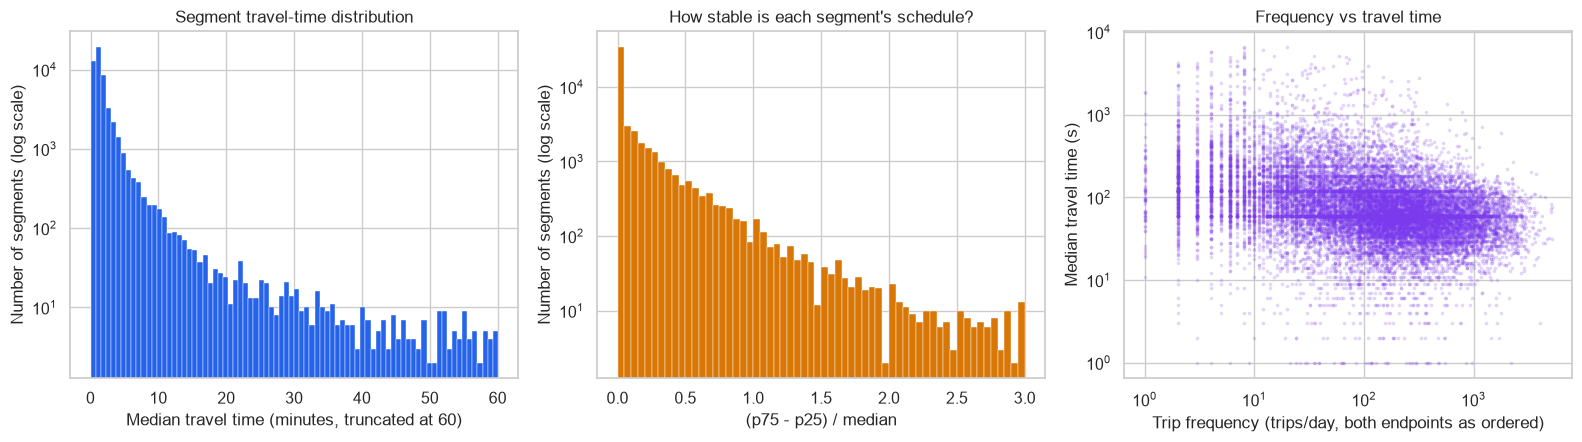


Spearman(trip_frequency, median_travel_seconds) = -0.368 - if this were near +/-1 the re-weighting would add nothing.


In [11]:
med_s = tt_edges["median_travel_seconds"].to_numpy(dtype=float)
rel_iqr = ((tt_edges["p75_travel_seconds"] - tt_edges["p25_travel_seconds"])
           / tt_edges["median_travel_seconds"].replace(0, np.nan)).to_numpy(dtype=float)

pct = np.percentile(med_s, [1, 25, 50, 75, 90, 99])
print("Median travel time per segment (seconds): "
      f"p1={pct[0]:.0f}  p25={pct[1]:.0f}  p50={pct[2]:.0f}  "
      f"p75={pct[3]:.0f}  p90={pct[4]:.0f}  p99={pct[5]:.0f}")
print(f"in minutes: p50={pct[2] / 60:.1f}  p90={pct[4] / 60:.1f}  p99={pct[5] / 60:.1f}")
print(f"segments over 30 minutes: {(med_s > 1800).sum():,} "
      f"({(med_s > 1800).mean():.2%})")
print(f"median relative IQR (p75-p25)/median: {np.nanmedian(rel_iqr):.2f}")
print(f"segments with a zero-width IQR (identical on every trip): "
      f"{(np.nan_to_num(rel_iqr) == 0).sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].hist(med_s / 60.0, bins=80, range=(0, 60), color="#2563eb",
             edgecolor="white", linewidth=0.3)
axes[0].set_yscale("log")
axes[0].set_xlabel("Median travel time (minutes, truncated at 60)")
axes[0].set_ylabel("Number of segments (log scale)")
axes[0].set_title("Segment travel-time distribution")

axes[1].hist(rel_iqr[np.isfinite(rel_iqr)], bins=60, range=(0, 3), color="#d97706",
             edgecolor="white", linewidth=0.3)
axes[1].set_yscale("log")
axes[1].set_xlabel("(p75 - p25) / median")
axes[1].set_ylabel("Number of segments (log scale)")
axes[1].set_title("How stable is each segment's schedule?")

sample = tt_edges.sample(min(20000, len(tt_edges)), random_state=PATH_SEED)
axes[2].scatter(sample["trip_frequency"].clip(lower=1),
                sample["median_travel_seconds"].clip(lower=1),
                s=3, alpha=0.15, color="#7c3aed")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("Trip frequency (trips/day, both endpoints as ordered)")
axes[2].set_ylabel("Median travel time (s)")
axes[2].set_title("Frequency vs travel time")

fig.tight_layout()
fig.savefig(FIGURES / "traveltime_distribution.png", dpi=FIG_DPI)
plt.show()

rho_freq_time = (tt_edges["trip_frequency"].corr(tt_edges["median_travel_seconds"],
                                                 method="spearman"))
print(f"\nSpearman(trip_frequency, median_travel_seconds) = {rho_freq_time:.3f} "
      "- if this were near +/-1 the re-weighting would add nothing.")

## 11. Compare hop-optimal and time-optimal routes

We sample 300 origin-destination pairs from the largest component and route each pair twice on the same graph. BFS minimizes the number of edges; Dijkstra minimizes the sum of `travel_seconds`. We record both station sequences, hop counts, scheduled durations, equality, time lost by using the hop route, and extra stops used by the time-optimal route.

This directly measures the cost of the hop assumption. In this sample only 0.3% of the two routes are identical. The median hop-optimal route is 40.7 scheduled minutes slower and takes 1.45 times the time of the time-optimal route. In 99% of pairs the faster route uses more stops, with a median of 12 extra stops.

These are timetable paths with no waiting or transfer penalty, so they are not complete passenger journey times. They still show that hop count and scheduled minutes choose very different paths.

300 origin-destination pairs routed twice in 4.8s

identical routes                        : 0.0% of pairs
median time lost by hop-routing         : 40.7 min
mean time lost by hop-routing           : 49.4 min
90th percentile time lost               : 109.9 min
median hop-path / time-path duration    : 1.48x
median extra stops on the time-optimal route: 12
pairs where the time-optimal route is LONGER in hops: 99.0%


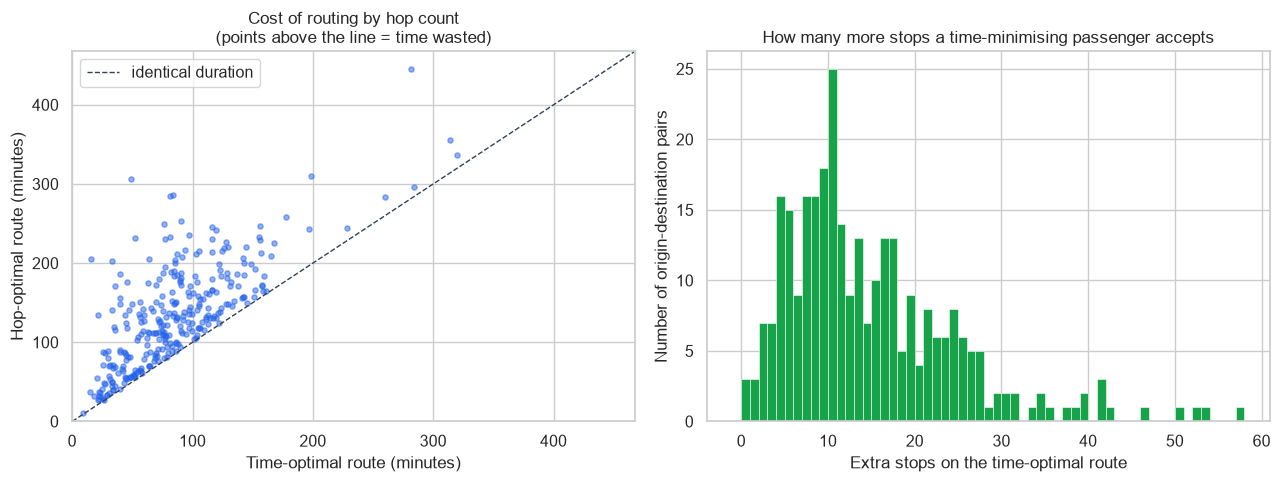

In [12]:
rng = random.Random(PATH_SEED)
lcc_nodes = list(Gc.nodes())

pairs = []
while len(pairs) < N_PATH_PAIRS:
    s, t = rng.choice(lcc_nodes), rng.choice(lcc_nodes)
    if s != t:
        pairs.append((s, t))


def path_seconds(graph, path):
    return sum(graph[a][b]["travel_seconds"] for a, b in zip(path, path[1:]))


t0 = time.time()
rows = []
for s, t in pairs:
    hop_path = nx.shortest_path(Gc, s, t)                              # BFS
    time_path = nx.shortest_path(Gc, s, t, weight="travel_seconds")    # Dijkstra
    rows.append({
        "source": s, "target": t,
        "hop_path_hops": len(hop_path) - 1,
        "time_path_hops": len(time_path) - 1,
        "hop_path_seconds": round(path_seconds(Gc, hop_path), 1),
        "time_path_seconds": round(path_seconds(Gc, time_path), 1),
        "same_path": hop_path == time_path,
    })
print(f"{len(rows)} origin-destination pairs routed twice in {time.time() - t0:.1f}s")

paths = pd.DataFrame(rows)
paths["extra_seconds_if_hop_routed"] = paths["hop_path_seconds"] - paths["time_path_seconds"]
paths["extra_hops_if_time_routed"] = paths["time_path_hops"] - paths["hop_path_hops"]
paths["time_penalty_ratio"] = (paths["hop_path_seconds"]
                               / paths["time_path_seconds"].replace(0, np.nan))
paths.to_csv(TABLES / "path_comparison.csv", index=False, encoding="utf-8-sig")

same_share = paths["same_path"].mean()
med_penalty = paths["extra_seconds_if_hop_routed"].median()
mean_penalty = paths["extra_seconds_if_hop_routed"].mean()
med_ratio = paths["time_penalty_ratio"].median()
p90_penalty = paths["extra_seconds_if_hop_routed"].quantile(0.90)

print(f"\nidentical routes                        : {same_share:.1%} of pairs")
print(f"median time lost by hop-routing         : {med_penalty / 60:.1f} min")
print(f"mean time lost by hop-routing           : {mean_penalty / 60:.1f} min")
print(f"90th percentile time lost               : {p90_penalty / 60:.1f} min")
print(f"median hop-path / time-path duration    : {med_ratio:.2f}x")
print(f"median extra stops on the time-optimal route: "
      f"{paths['extra_hops_if_time_routed'].median():.0f}")
print(f"pairs where the time-optimal route is LONGER in hops: "
      f"{(paths['extra_hops_if_time_routed'] > 0).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = max(paths["hop_path_seconds"].max(), paths["time_path_seconds"].max()) / 60 * 1.05
axes[0].scatter(paths["time_path_seconds"] / 60, paths["hop_path_seconds"] / 60,
                s=14, alpha=0.5, color="#2563eb")
axes[0].plot([0, lim], [0, lim], ls="--", lw=1, color="#334155",
             label="identical duration")
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("Time-optimal route (minutes)")
axes[0].set_ylabel("Hop-optimal route (minutes)")
axes[0].set_title("Cost of routing by hop count\n(points above the line = time wasted)")
axes[0].legend()

axes[1].hist(paths["extra_hops_if_time_routed"], bins=range(
    int(paths["extra_hops_if_time_routed"].min()) - 1,
    int(paths["extra_hops_if_time_routed"].max()) + 2),
    color="#16a34a", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Extra stops on the time-optimal route")
axes[1].set_ylabel("Number of origin-destination pairs")
axes[1].set_title("How many more stops a time-minimising passenger accepts")

fig.tight_layout()
fig.savefig(FIGURES / "path_comparison.png", dpi=FIG_DPI)
plt.show()

## 12. Recompute betweenness with time weights and a matched control

We estimate travel-time betweenness on the largest time-graph component using 200 sampled sources. To isolate the effect of weighting, we also calculate unweighted hop betweenness on the **same graph with the same `k`, seed, and source sample**. The only difference between those two runs is whether a path minimizes seconds or hops.

We retain notebook 04's hop estimate as a third column. That value uses a different sample and a slightly different graph, so its disagreement with our matched hop control gives a sampling-and-graph noise reference.

The weighted run uses Dijkstra and is slower. Many low-centrality stations still receive zero under a 200-source sample; we treat those zeros as sampling outcomes, not proof that a station is unused.

In [13]:
bt_tt = bt_hop = None
k_eff = None

if RUN_BETWEENNESS:
    k_eff = min(K_BETWEENNESS, Gc.number_of_nodes())
    print(f"LCC: {Gc.number_of_nodes():,} nodes / {Gc.number_of_edges():,} edges | "
          f"k = {k_eff} sources ({k_eff / Gc.number_of_nodes():.2%} of the LCC)")

    print("  computing travel-time weighted betweenness ...", flush=True)
    t0 = time.time()
    bt_tt = nx.betweenness_centrality(Gc, k=k_eff, seed=BETWEENNESS_SEED,
                                      normalized=True, weight="travel_seconds")
    print(f"  travel-time (weighted) betweenness : {time.time() - t0:,.0f}s")

    print("  computing hop-count control betweenness ...", flush=True)
    t0 = time.time()
    bt_hop = nx.betweenness_centrality(Gc, k=k_eff, seed=BETWEENNESS_SEED,
                                       normalized=True, weight=None)
    print(f"  hop-count control (same k, same seed, same sources): {time.time() - t0:,.0f}s")

    nz_tt = sum(1 for v in bt_tt.values() if v > 0)
    nz_hop = sum(1 for v in bt_hop.values() if v > 0)
    print(f"\nnon-zero estimates: travel-time {nz_tt:,} | hop control {nz_hop:,} "
          f"of {len(bt_tt):,} stations")
    print("Stations at zero were simply never on a sampled shortest path - with k = "
          f"{k_eff} sources that is expected, not a finding.")
else:
    print("RUN_BETWEENNESS is False - sections 12-14 are skipped. "
          "The contract outputs of this notebook are already written.")

LCC: 30,224 nodes / 51,416 edges | k = 200 sources (0.66% of the LCC)
  computing travel-time weighted betweenness ...
  travel-time (weighted) betweenness : 18s
  computing hop-count control betweenness ...
  hop-count control (same k, same seed, same sources): 10s

non-zero estimates: travel-time 26,319 | hop control 27,289 of 30,224 stations
Stations at zero were simply never on a sampled shortest path - with k = 200 sources that is expected, not a finding.


## 13. Compare the betweenness rankings

We join the three estimates by station ID and calculate Spearman correlation over all stations, correlation where either value is positive, and overlap among the top 10, 50, and 100.

The matched comparison is the main result. Travel-time versus hop control has Spearman 0.610 over all stations and only 12 shared stations in the top 50 (24% overlap). The two hop estimates, despite different samples, have Spearman 0.956 and 76% top-50 overlap. The much larger disagreement in the time-weighted pair is therefore well beyond the sampling noise we see between two hop runs.

We save the full station table and the compact agreement table so both values and ranking summaries remain available.

In [14]:
if RUN_BETWEENNESS:
    nb04 = pd.read_csv(METRICS_CSV, dtype={"stop_id": str}, encoding="utf-8-sig")
    if "approx_betweenness" not in nb04.columns:
        raise KeyError("stop_metrics.csv has no 'approx_betweenness' column - "
                       "re-run notebook 04_centrality_analysis.")
    nb04_bt = dict(zip(nb04["stop_id"], nb04["approx_betweenness"].astype(float)))

    bt = pd.DataFrame({
        "stop_id": list(Gc.nodes()),
    })
    bt["stop_name"] = bt["stop_id"].map(lambda n: Gc.nodes[n].get("stop_name", ""))
    bt["region"] = bt["stop_id"].map(lambda n: Gc.nodes[n].get("region", ""))
    bt["lat"] = bt["stop_id"].map(lambda n: Gc.nodes[n].get("lat", np.nan))
    bt["lon"] = bt["stop_id"].map(lambda n: Gc.nodes[n].get("lon", np.nan))
    bt["bt_traveltime"] = bt["stop_id"].map(bt_tt).fillna(0.0)
    bt["bt_hop_control"] = bt["stop_id"].map(bt_hop).fillna(0.0)
    bt["bt_hop_nb04"] = bt["stop_id"].map(nb04_bt).fillna(0.0)
    bt["rank_traveltime"] = bt["bt_traveltime"].rank(ascending=False, method="min").astype(int)
    bt["rank_hop_control"] = bt["bt_hop_control"].rank(ascending=False, method="min").astype(int)
    bt["rank_hop_nb04"] = bt["bt_hop_nb04"].rank(ascending=False, method="min").astype(int)
    bt["rank_shift_vs_control"] = bt["rank_hop_control"] - bt["rank_traveltime"]
    bt["rank_shift_vs_nb04"] = bt["rank_hop_nb04"] - bt["rank_traveltime"]
    bt = bt.sort_values("bt_traveltime", ascending=False).reset_index(drop=True)
    bt.to_csv(TABLES / "betweenness_traveltime.csv", index=False, encoding="utf-8-sig")

    missing_in_nb04 = int((~bt["stop_id"].isin(set(nb04_bt))).sum())

    def agreement(col_a, col_b, label):
        rho_all = bt[col_a].corr(bt[col_b], method="spearman")
        sub = bt[(bt[col_a] > 0) | (bt[col_b] > 0)]
        rho_pos = sub[col_a].corr(sub[col_b], method="spearman") if len(sub) > 2 else np.nan
        out = {"comparison": label, "n_stations": len(bt),
               "n_positive_either": len(sub),
               "spearman_all": round(float(rho_all), 4),
               "spearman_positive_either": round(float(rho_pos), 4)}
        for n in (10, 50, 100):
            a = set(bt.nlargest(n, col_a)["stop_id"])
            b = set(bt.nlargest(n, col_b)["stop_id"])
            out[f"top{n}_overlap"] = round(len(a & b) / n, 3)
        return out

    agree = pd.DataFrame([
        agreement("bt_traveltime", "bt_hop_control",
                  "travel-time vs hop control (same sample - clean)"),
        agreement("bt_traveltime", "bt_hop_nb04",
                  "travel-time vs notebook 04 (different sample - practical)"),
        agreement("bt_hop_control", "bt_hop_nb04",
                  "hop control vs notebook 04 (sampling noise floor)"),
    ])
    agree.to_csv(TABLES / "betweenness_agreement.csv", index=False, encoding="utf-8-sig")
    print(f"stations in the travel-time LCC missing from notebook 04: {missing_in_nb04:,}")
    display(agree.T)
else:
    bt = agree = None

stations in the travel-time LCC missing from notebook 04: 0


,0,1,2
comparison,travel-time vs hop control (same sample - clean),travel-time vs notebook 04 (different sample -...,hop control vs notebook 04 (sampling noise floor)
n_stations,30224,30224,30224
n_positive_either,28521,28678,27837
spearman_all,0.6109,0.5854,0.9556
spearman_positive_either,0.5515,0.528,0.9446
top10_overlap,0.2,0.2,0.9
top50_overlap,0.28,0.34,0.8
top100_overlap,0.27,0.27,0.76


### Use the hop-versus-hop row as the noise reference

We read the matched time-versus-hop row together with the hop-control-versus-notebook-04 row. The second comparison is not expected to equal one because it uses a different source sample and a graph with a few more edges, but it tells us how stable a hop ranking is under those changes.

Here the hop-versus-hop correlation is 0.9558 with 76% top-50 overlap, while time versus matched hop is 0.6100 with 24% overlap. The weighting effect is therefore much larger than the observed sampling difference at these settings. The scatter plots show the same comparison on ranks, where the separation is easier to see.

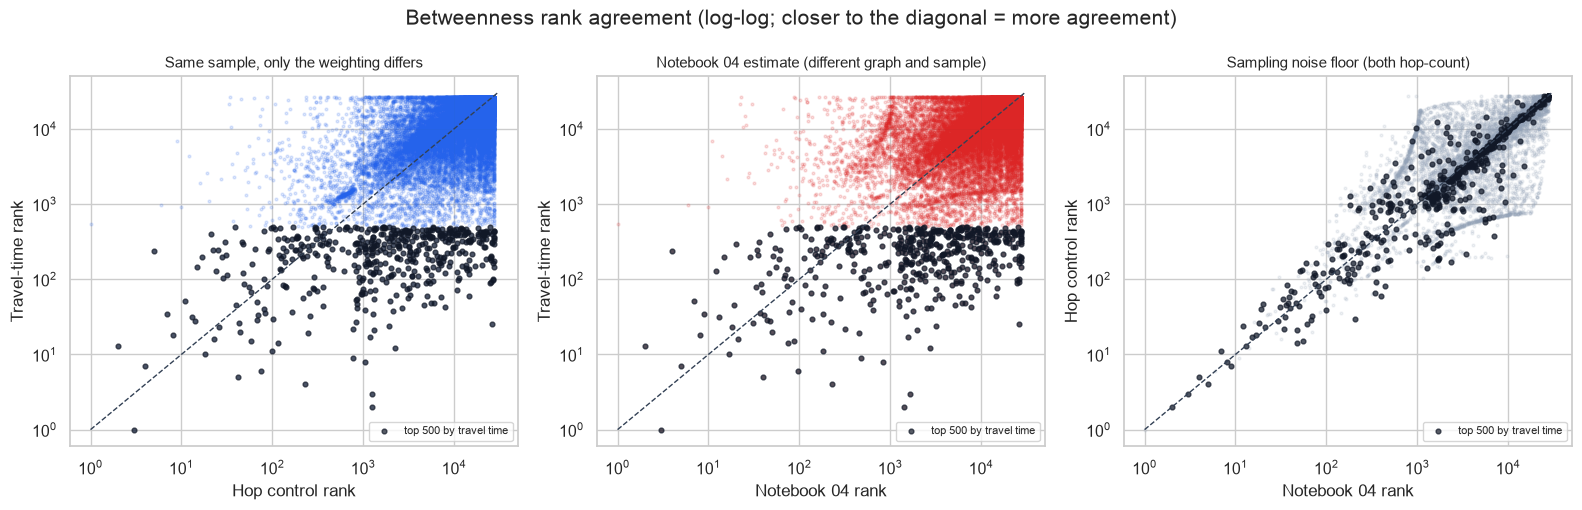

In [15]:
if RUN_BETWEENNESS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
    comparisons = [
        ("rank_hop_control", "rank_traveltime", "Hop control rank", "Travel-time rank",
         "Same sample, only the weighting differs", "#2563eb"),
        ("rank_hop_nb04", "rank_traveltime", "Notebook 04 rank", "Travel-time rank",
         "Notebook 04 estimate (different graph and sample)", "#dc2626"),
        ("rank_hop_nb04", "rank_hop_control", "Notebook 04 rank", "Hop control rank",
         "Sampling noise floor (both hop-count)", "#94a3b8"),
    ]
    pool = bt.nsmallest(RANK_POOL, "rank_traveltime")
    for ax, (xc, yc, xl, yl, title, color) in zip(axes, comparisons):
        ax.scatter(bt[xc], bt[yc], s=4, alpha=0.15, color=color)
        ax.scatter(pool[xc], pool[yc], s=12, alpha=0.7, color="#111827",
                   label=f"top {RANK_POOL} by travel time")
        lim = len(bt)
        ax.plot([1, lim], [1, lim], ls="--", lw=1, color="#334155")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=8, loc="lower right")
    fig.suptitle("Betweenness rank agreement (log-log; closer to the diagonal = more agreement)")
    fig.tight_layout()
    fig.savefig(FIGURES / "betweenness_rank_agreement.png", dpi=FIG_DPI)
    plt.show()

## 14. Identify the largest rank changes

We limit the mover analysis to stations ranked in the top `RANK_POOL` under at least one of the two matched estimates. Outside that pool, sampled zeros and tied low values can create very large but meaningless numeric rank shifts.

`rank_shift_vs_control` is hop rank minus travel-time rank. Positive values mean a station becomes more central when paths minimize seconds; negative values mean it loses importance. We save the full pool and print the leading gains and losses with station names and regions.

The pool contains 862 stations in this run, and the median absolute shift within it is 1,961 rank positions. We use the station list and map to see whether the changes align with fast corridors and slow dense stop chains rather than treating rank movement alone as an explanation.

mover pool: 873 stations (top 500 under either weighting)
median |rank shift| inside the pool: 1920 places

Rose most under travel-time weighting (gained importance):


,stop_id,stop_name,region,bt_traveltime,bt_hop_control,rank_traveltime,rank_hop_control,rank_shift_vs_control,rank_shift_vs_nb04
144,4216,צומת מצפה,North,0.022007,0.000000e+00,145,27290,27145,27396
176,19343,צומת ח'לית שריף/טמרה,North,0.019761,0.000000e+00,177,27290,27113,27364
292,51777,צומת סאג'ור מערב,North,0.014028,0.000000e+00,293,27290,26997,27248
98,35111,מסעף מחנה עמוס,North,0.026880,5.035104e-08,99,27075,26976,24416
332,15096,צומת ברורים,Center,0.012808,0.000000e+00,333,27290,26957,27208
356,4304,מסעף טבח'ה,North,0.012375,0.000000e+00,357,27290,26933,27184
359,4299,חוף אמנון,North,0.012314,0.000000e+00,360,27290,26930,27181
423,35604,בסיס נ.מ. אילת,South,0.011373,0.000000e+00,424,27290,26866,27117
438,26729,מחנה אריאל שרון / כביש 224,South,0.011211,0.000000e+00,439,27290,26851,27102
443,11970,שדרות דוד טוביהו/מוטה גור,South,0.011166,0.000000e+00,444,27290,26846,27097


Fell most under travel-time weighting (were hop-count artefacts):


,stop_id,stop_name,region,bt_traveltime,bt_hop_control,rank_traveltime,rank_hop_control,rank_shift_vs_control,rank_shift_vs_nb04
27680,47911,ת. מרכזית ק''ש/רציפים,North,0.000000e+00,0.023795,26320,34,-26286,-26297
26632,42405,תחנת התרעננות/צומת מגידו,North,0.000000e+00,0.015457,26320,88,-26232,-26232
29398,49800,מסוף מודיעין עילית/הורדה,Center,0.000000e+00,0.008840,26320,235,-26085,-26129
28404,51588,אורחות צדיקים/חובת הלבבות,Center,0.000000e+00,0.007745,26320,289,-26031,-24240
26645,42400,מסוף חצור הגלילית/הורדה,North,0.000000e+00,0.007032,26320,335,-25985,-26154
28104,47918,ת.מרכזית באר שבע/רציפים בינעירוני,South,0.000000e+00,0.006304,26320,399,-25921,-25440
26626,27040,בסיס אורים,South,0.000000e+00,0.006211,26320,415,-25905,-25073
28575,48874,סחלב/גרנית,South,0.000000e+00,0.005690,26320,479,-25841,-23602
25741,2945,רש''י/חטיבת הראל,Center,6.617696e-07,0.017787,25671,63,-25608,-25581
25184,5267,הגליל/הקישון,North,2.316194e-06,0.021836,25162,45,-25117,-25045


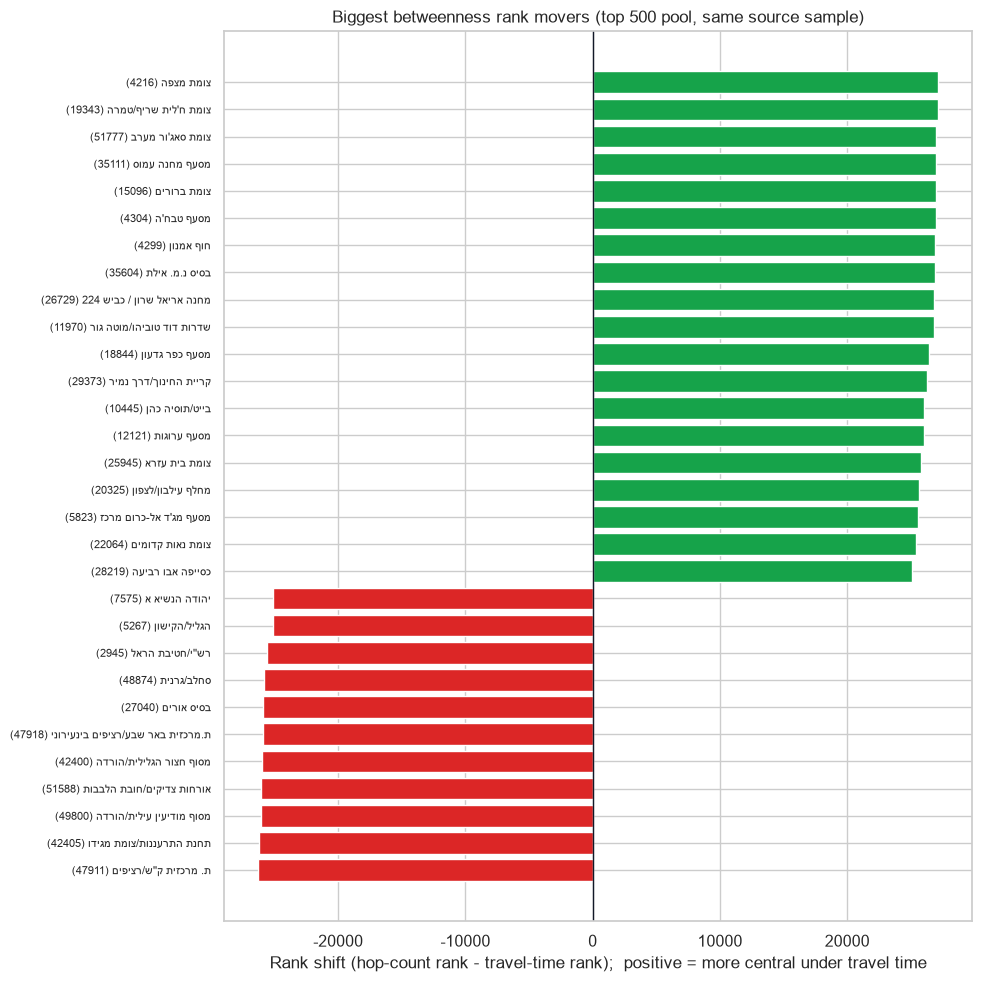

In [16]:
if RUN_BETWEENNESS:
    in_pool = (bt["rank_traveltime"] <= RANK_POOL) | (bt["rank_hop_control"] <= RANK_POOL)
    movers = bt.loc[in_pool].copy()
    movers["abs_shift"] = movers["rank_shift_vs_control"].abs()
    movers = movers.sort_values("abs_shift", ascending=False)

    cols = ["stop_id", "stop_name", "region", "bt_traveltime", "bt_hop_control",
            "rank_traveltime", "rank_hop_control", "rank_shift_vs_control",
            "rank_shift_vs_nb04"]
    movers[cols + ["abs_shift"]].to_csv(
        TABLES / "betweenness_rank_movers.csv", index=False, encoding="utf-8-sig")

    print(f"mover pool: {len(movers):,} stations (top {RANK_POOL} under either weighting)")
    print(f"median |rank shift| inside the pool: "
          f"{movers['abs_shift'].median():.0f} places")
    print("\nRose most under travel-time weighting (gained importance):")
    display(movers.nlargest(TOP_N, "rank_shift_vs_control")[cols])
    print("Fell most under travel-time weighting (were hop-count artefacts):")
    display(movers.nsmallest(TOP_N, "rank_shift_vs_control")[cols])

    top_movers = movers.nlargest(2 * TOP_N, "abs_shift").sort_values("rank_shift_vs_control")
    labels = [f"{(n or sid)} ({sid})" for n, sid
              in zip(top_movers["stop_name"], top_movers["stop_id"])]
    colors = ["#dc2626" if v < 0 else "#16a34a"
              for v in top_movers["rank_shift_vs_control"]]

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.barh(range(len(top_movers)), top_movers["rank_shift_vs_control"], color=colors)
    ax.set_yticks(range(len(top_movers)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color="#111827", lw=1)
    ax.set_xlabel("Rank shift (hop-count rank - travel-time rank);  "
                  "positive = more central under travel time")
    ax.set_title(f"Biggest betweenness rank movers (top {RANK_POOL} pool, same source sample)")
    fig.tight_layout()
    fig.savefig(FIGURES / "betweenness_rank_movers.png", dpi=FIG_DPI)
    plt.show()

### Map the two top-50 lists

We plot the 50 highest travel-time-betweenness stations and 50 highest matched hop-betweenness stations on the same country map, highlighting the 12 stations they share. This gives geographic context to the 24% overlap.

If time weighting favors long, fast corridors while hop weighting favors dense urban shortcut positions, their map patterns should differ. The map is a descriptive check on that mechanism; the agreement table remains the quantitative result.

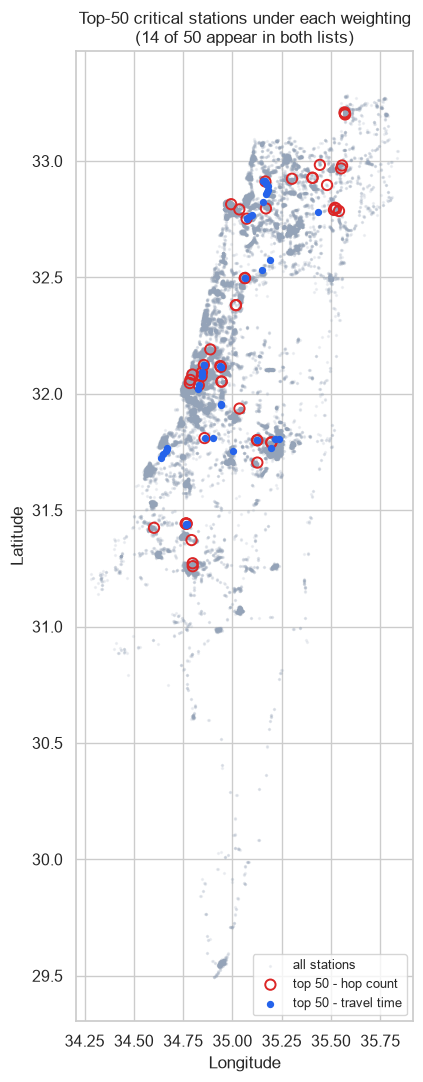

stations on both shortlists: 14 / 50


In [17]:
if RUN_BETWEENNESS:
    geo = bt.dropna(subset=["lat", "lon"])
    top_tt = geo.nsmallest(50, "rank_traveltime")
    top_hop = geo.nsmallest(50, "rank_hop_control")
    shared = set(top_tt["stop_id"]) & set(top_hop["stop_id"])

    fig, ax = plt.subplots(figsize=(8, 11))
    ax.scatter(geo["lon"], geo["lat"], s=2, alpha=0.12, color="#94a3b8",
               label="all stations")
    ax.scatter(top_hop["lon"], top_hop["lat"], s=55, facecolors="none",
               edgecolors="#dc2626", linewidths=1.4, label="top 50 - hop count")
    ax.scatter(top_tt["lon"], top_tt["lat"], s=18, color="#2563eb",
               label="top 50 - travel time", zorder=5)
    ax.set_aspect(1 / np.cos(np.deg2rad(float(geo["lat"].mean()))))
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("Top-50 critical stations under each weighting\n"
                 f"({len(shared)} of 50 appear in both lists)")
    ax.legend(loc="lower right", fontsize=9)
    fig.tight_layout()
    fig.savefig(FIGURES / "top50_shortlist_map.png", dpi=FIG_DPI)
    plt.show()
    print(f"stations on both shortlists: {len(shared)} / 50")

## 15. Save the summary and contract artifacts

We gather graph size, thresholds, every discard counter, travel-time percentiles, path-comparison statistics, and betweenness agreement values in `traveltime_summary.json`. We also check the directed edge table, graph pickle, comparison tables, mover table, and figures and print their sizes.

This gives later notebooks the weighted graph and its assumptions without requiring another pass through `stop_times.txt`.

In [18]:
summary = {
    "stage": "18_travel_time_network",
    "edge_weight": "median scheduled travel time in seconds (attribute 'travel_seconds', "
                   "mirrored to 'weight')",
    "thresholds": {
        "min_travel_seconds": MIN_TRAVEL_SECONDS,
        "max_travel_seconds": MAX_TRAVEL_SECONDS,
        "min_observations": MIN_OBSERVATIONS,
    },
    "streaming": stream_stats,
    "discards": {k: int(v) for k, v in buckets.items()},
    "graph": {
        "nodes": Gt.number_of_nodes(),
        "undirected_edges": Gt.number_of_edges(),
        "directed_edges_with_traveltime": int(len(tt_edges)),
        "stage02_segments_without_traveltime": int(len(missing_directed)),
        "connected_components": len(components),
        "largest_component_nodes": Gc.number_of_nodes(),
        "largest_component_share": round(lcc_share, 4),
    },
    "travel_time_seconds": {
        "p1": float(pct[0]), "p25": float(pct[1]), "p50": float(pct[2]),
        "p75": float(pct[3]), "p90": float(pct[4]), "p99": float(pct[5]),
        "median_relative_iqr": float(round(np.nanmedian(rel_iqr), 4)),
        "spearman_frequency_vs_time": float(round(rho_freq_time, 4)),
    },
    "path_comparison": {
        "pairs": int(len(paths)),
        "identical_route_share": float(round(same_share, 4)),
        "median_seconds_lost_by_hop_routing": float(med_penalty),
        "mean_seconds_lost_by_hop_routing": float(round(mean_penalty, 1)),
        "p90_seconds_lost_by_hop_routing": float(p90_penalty),
        "median_duration_ratio": float(round(med_ratio, 4)),
        "median_extra_hops_on_time_route":
            float(paths["extra_hops_if_time_routed"].median()),
    },
    "betweenness": (
        {
            "k_samples": int(k_eff),
            "seed": BETWEENNESS_SEED,
            "agreement": agree.to_dict("records"),
            "median_abs_rank_shift_in_pool": float(movers["abs_shift"].median()),
            "rank_pool": RANK_POOL,
        }
        if RUN_BETWEENNESS else {"skipped": True}
    ),
}

with open(STAGE / "traveltime_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

written = [
    TABLES / "edges_traveltime.csv",
    TABLES / "edges_traveltime_undirected.csv",
    STAGE / "graph_traveltime.pkl",
    STAGE / "traveltime_summary.json",
    TABLES / "discard_reasons.csv",
    TABLES / "path_comparison.csv",
]
if RUN_BETWEENNESS:
    written += [TABLES / "betweenness_traveltime.csv",
                TABLES / "betweenness_agreement.csv",
                TABLES / "betweenness_rank_movers.csv"]

print("Written:")
for p in written:
    print(f"  {p}  ({p.stat().st_size / 1024:,.0f} KB)")
print("\nSummary (graph + path comparison):")
print(json.dumps({k: summary[k] for k in ("graph", "path_comparison")},
                 indent=2, ensure_ascii=False))

Written:
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/edges_traveltime.csv  (1,750 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/edges_traveltime_undirected.csv  (1,204 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/graph_traveltime.pkl  (5,545 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/traveltime_summary.json  (3 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/discard_reasons.csv  (0 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/path_comparison.csv  (19 KB)
  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/18_travel_time_network/tables/betweenness_traveltime.csv  (4,449 KB)
  /Users/seanfourman/Desktop/israel-tra

## Conclusion

The travel-time graph keeps almost all of the topological graph while changing what a shortest path means. We retain 15,196,995 valid consecutive-stop observations and build 51,907 directed weighted segments; only 92 directed edges from the hop graph lack a valid duration. The undirected graph has 30,463 nodes and 51,680 edges, with 99.24% of nodes in its largest component.

The main data limitation is timestamp resolution. We discard 93,778 non-positive observations, mostly adjacent stops carrying the same time. That is 0.61% of consecutive pairs. Removing them avoids artificial near-zero shortcuts but biases surviving medians upward and disproportionately affects short urban segments. Arrival and departure are identical on every row, so the weights contain no separate dwell time.

The edge weights look plausible as scheduled segment times: the median is 66 seconds, the 90th percentile is four minutes, and the 99th is about 22.8 minutes. Still, these are timetable values. They exclude waiting for a service, transfer time, walking, congestion, and delay, so they are not complete passenger journey times.

Hop routing and time routing are not close substitutes in this graph. Only 0.3% of 300 sampled origin-destination pairs use the same station sequence. The hop-optimal route loses a median 40.7 scheduled minutes, while the faster route accepts a median 12 extra stops. This tells us that minimizing station count is a poor proxy for minimizing scheduled travel time.

The critical-station ranking changes far beyond the sampling noise. Travel-time betweenness versus the matched hop control has Spearman correlation 0.610 and 24% top-50 overlap. Two hop estimates with different samples have correlation 0.956 and 76% top-50 overlap. Since only 12 stations appear in both matched top-50 lists, we should treat hop-based and time-based betweenness as different notions of criticality rather than small variants of one ranking.

The betweenness values are still sampled from only 200 sources, so fine ordering within the long tail is unreliable. That is why we restrict the mover table to stations near the top under at least one weighting. The strong matched-control difference supports the weighting conclusion, but a larger source sample would make individual station ranks more stable.

Finally, the graph still models scheduled supply rather than passenger demand. Time weights make routing more realistic, but they do not tell us how many people are affected. We need to combine this graph with demand or exposure information before turning centrality changes into operational priorities.